In [1]:
# AI-Powered Customer Churn Prediction & Analytics Platform 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('../datasets/Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Churn Distributiion :")
print(df['Churn'].value_counts())

Churn Distributiion :
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
print("\n Churn Percentage ")
print(df['Churn'].value_counts(normalize = True ) * 100)


 Churn Percentage 
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Remove the Unneccessary Column

In [13]:
df = df.drop('customerID' ,axis = 1)

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
# Data Types Conversion 
df[df['TotalCharges'].isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [17]:
df[df['TotalCharges'].isna()]['TotalCharges']

Series([], Name: TotalCharges, dtype: object)

In [18]:
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [19]:
df['TotalCharges'] = df['TotalCharges'].replace(' ' , 0)

In [20]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [21]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [22]:
# Seperate Numerical and Categorical Column 

In [23]:
numerical_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [24]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [25]:
categorical_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

In [26]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [27]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTypes:")
print(type(numerical_features))
print(type(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Types:
<class 'list'>
<class 'list'>


In [89]:
# Seperate Features and Target Variebles 

In [28]:
X = df.drop('Churn' , axis = 1)
y = df['Churn'] 

In [29]:
# Encode the Target Varieble

In [30]:
y = y.map({'No': 0 ,'Yes':1})

In [31]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [32]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [33]:
X.shape

(7043, 19)

In [34]:
y.shape

(7043,)

In [97]:
# Train - Test Split 

In [35]:
from sklearn.model_selection import train_test_split

In [37]:
X_train , X_test , y_train , y_test = train_test_split (
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y) #  We want approximately the same class distribution in both train and test


In [38]:
X_train.shape , X_test.shape

((5634, 19), (1409, 19))

In [39]:
# Create Preprocessor 

In [40]:
preprocessor = ColumnTransformer(transformers = [
    (
        'num',
        StandardScaler(),
        numerical_features
        
    ),
    (
        'cat',
        OneHotEncoder(handle_unknown = 'ignore'),
        categorical_features
    )
]
)

In [41]:
# Standard Scaler 

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
# OneHotEncoder

In [45]:
from sklearn.preprocessing import OneHotEncoder

In [46]:
encoder = OneHotEncoder(handle_unknown = 'ignore')

In [47]:
# ColumnTransformaer - In machine learning, a ColumnTransformer is a feature available in Python's scikit-learn library that allows you to apply separate data preprocessing steps to different columns (features) in your dataset simultaneously


In [48]:
# Create  Logistic Regresssion Model

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression( max_iter = 1000 ,
                            random_state = 43)

In [51]:
# Create Pipeline 

In [52]:
pipeline = Pipeline( 
    steps = [
        ('preprocessor', preprocessor),
        ('model' , model)
    ])

In [53]:
# Train the Model 

In [54]:
pipeline.fit(X_train,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=43))])

In [55]:
# Predictions 

In [56]:
y_pred = pipeline.predict(X_test)

In [57]:
# Prediction Probabilities 

In [87]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [59]:
print("Model Trainnning Completed")

Model Trainnning Completed


In [60]:
# Model Evaluation 

In [62]:
from sklearn.metrics import confusion_matrix

In [63]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[926 109]
 [165 209]]


'''
                Predicted No Churn	Predicted Churn
Actual No Churn	     TN	                     FP
Actual Churn	     FN	                     TP

True Negative 
Actual = No Churn
Predicted = No Churn

Example:

Actual :     No
Model  :     No

Correct prediction.

What is TP?

True Positive

Actual = Churn
Predicted = Churn

Example:

Actual:     Yes
Model:      Yes

Correct prediction.

This is particularly important because we successfully detected a customer who actually churned.

What is FP?

False Positive

Actual = No Churn
Predicted = Churn

Example:

Actual:     No
Model:      Yes

 Model incorrectly says the customer will churn.

This is also called a Type I error.

What is FN?

False Negative

Actual = Churn
Predicted = No Churn

Example:

Actual:     Yes
Model:      No

 Model missed a customer who actually churned.

This is also called a Type II error.
'''

In [66]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 926
FP: 109
FN: 165
TP: 209


In [67]:
# Visualize the Confusion Martrix 

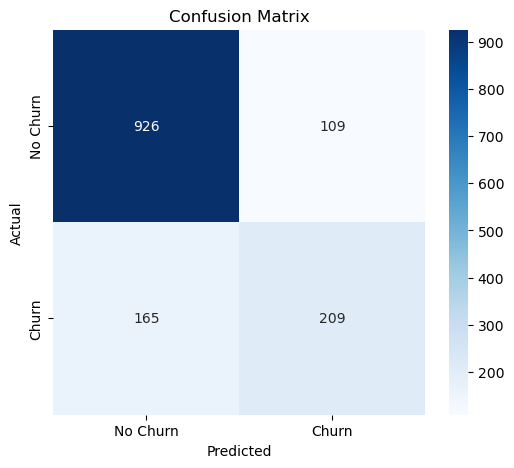

In [69]:
plt.figure(figsize = (6,5))
sns.heatmap(cm,annot = True ,fmt = 'd',
            cmap = 'Blues',
            xticklabels =['No Churn','Churn'],
            yticklabels =['No Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [70]:
# Calculate Accuracy , Precision , Recall , F1 Score

In [71]:
from sklearn.metrics import ( accuracy_score , precision_score,
recall_score , f1_score)

In [73]:
# Accuracy 
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy " , accuracy)
print("Accuracy (%) " , accuracy* 100)

Accuracy  0.8055358410220014
Accuracy (%)  80.55358410220013


In [74]:
# Precision
precision = precision_score(y_test , y_pred)
print("Precision :", precision)
print("Precision (%):",precision * 100)

Precision : 0.6572327044025157
Precision (%): 65.72327044025157


In [75]:
# Recall 
recall = recall_score(y_test , y_pred)
print("Recall:", recall)
print("Recall (%):", recall * 100)

Recall: 0.5588235294117647
Recall (%): 55.88235294117647


In [76]:
# F1 Score 

In [77]:
f1 = f1_score(y_test , y_pred)
print("F1 Score:",f1)

F1 Score: 0.6040462427745664


In [78]:
# Classification Report 

In [79]:
from sklearn.metrics import classification_report

In [134]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#  model predictions
y_pred = pipeline.predict(X_test)

#  model probabilities
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== NORMAL MODEL TEST RESULTS =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

===== NORMAL MODEL TEST RESULTS =====
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040
ROC-AUC  : 0.8421


In [139]:
print(classification_report(
    y_test , 
    y_pred,
    target_names = ['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [140]:
# ROC Curve And ROC AUC

In [141]:
from sklearn.metrics import roc_curve , roc_auc_score

In [142]:
# Calculate the ROC

In [143]:
fpr , tpr , thresholds = roc_curve(y_test , y_prob)

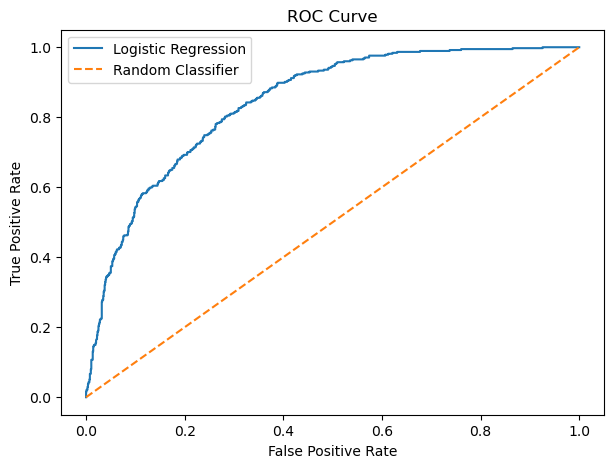

In [144]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

In [145]:
# Calculate The ROC - AUC 

In [146]:
auc = roc_auc_score(y_test , y_prob)
print("ROC- AUC " , auc)

ROC- AUC  0.8421349040274871


In [147]:
# Save model .pkl

In [148]:
import pickle

In [149]:
with open('../models/churn_pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

In [150]:
with open('../models/churn_pipeline.pkl','rb') as file:
    loaded_model = pickle.load(file)

In [151]:
test_predictions = loaded_model.predict(X_test)
print(test_predictions[:10])

[0 1 0 0 0 1 0 0 0 0]


In [152]:
test_probabilities = loaded_model.predict_proba(X_test)
print(test_probabilities[:5])

[[0.95408007 0.04591993]
 [0.31628655 0.68371345]
 [0.94106015 0.05893985]
 [0.59816471 0.40183529]
 [0.97857574 0.02142426]]


In [153]:
churn_probability = loaded_model.predict_proba(X_test)[:, 1]

In [154]:
churn_probability 

array([0.04591993, 0.68371345, 0.05893985, ..., 0.15442215, 0.00428645,
       0.00628801], shape=(1409,))

In [155]:
# Test New Customer
new_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [5],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.50],
    'TotalCharges': [427.50]
})

In [156]:
# Make Prediction 

In [157]:
prediction = loaded_model.predict(new_customer)
print(prediction)

[1]


In [158]:
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is unlikely to churn")

Customer is likely to churn


In [159]:
# Apply GridSearch CV

In [160]:
# Creates Parameter Grid

In [161]:
params = {
    'model__C' :[0.01 ,0.1 ,1 ,10 ,100],
    'model__penalty' : ['l2'],
    'model__solver' : ['lbfgs']
}

In [162]:
from sklearn.model_selection import GridSearchCV

In [163]:
grid_search = GridSearchCV( estimator = pipeline ,
                            param_grid = params,
                            cv = 5,
                            scoring = 'roc_auc',
                            n_jobs = -1)

In [164]:
grid_search.fit(X_train ,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=43))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='roc_auc')

In [165]:
print("Best  Parameter")
print(grid_search.best_params_)

Best  Parameter
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


In [166]:
# Cross Validation Score

In [167]:
print("Best CV ROC - AUC:")
print(grid_search.best_score_)

Best CV ROC - AUC:
0.8459390177818094


In [168]:
best_pipeline = grid_search.best_estimator_

In [169]:
# Test and Tuned Model

In [173]:
y_pred_tuned = best_pipeline.predict(X_test)

In [174]:
y_prob_tuned = best_pipeline.predict_proba(X_test)[:,1]

In [175]:
# Evualuate The Tuned Model 

In [176]:
from sklearn.metrics import (accuracy_score,
precision_score,recall_score , f1_score , roc_auc_score)


In [177]:
accuracy = accuracy_score(y_test, y_pred_tuned)

precision = precision_score(y_test, y_pred_tuned)

recall = recall_score(y_test, y_pred_tuned)

f1 = f1_score(y_test, y_pred_tuned)

roc_auc = roc_auc_score(y_test, y_prob_tuned)

In [178]:
print("Tuned Model Performance")
print("-----------------------")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Tuned Model Performance
-----------------------
Accuracy : 0.8048
Precision: 0.6552
Recall   : 0.5588
F1 Score : 0.6032
ROC-AUC  : 0.8412


In [179]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_tuned,target_names =['No Churn' ,'Churn']
                           )
     )

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



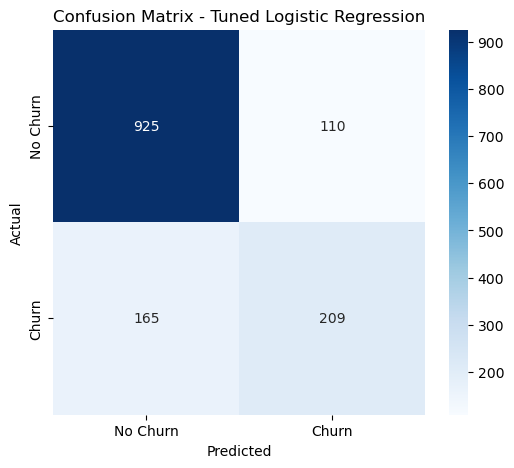

In [180]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')

plt.show()

In [181]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open(
    '../models/churn_logistic_regression_final.pkl',
    'wb'
) as file:
    pickle.dump(best_pipeline, file)

print("Final tuned model saved successfully!")

Final tuned model saved successfully!


In [130]:
with open('../models/churn_logistic_regression_final.pkl','rb') as file:
    final_model = pickle.load(file)
    

In [182]:
prediction = final_model.predict(new_customer)[0]

probability = final_model.predict_proba(
    new_customer
)[0][1]

print("--------------------------------")
print(" FINAL CUSTOMER CHURN PREDICTION")
print("--------------------------------")

print(f"Churn Probability: {probability * 100:.2f}%")

if prediction == 1:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")

--------------------------------
 FINAL CUSTOMER CHURN PREDICTION
--------------------------------
Churn Probability: 84.05%
Prediction: Churn


In [183]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Tuned model predictions
y_pred_tuned = best_pipeline.predict(X_test)

# Tuned model probabilities
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("===== TUNED MODEL TEST RESULTS =====")

print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

===== TUNED MODEL TEST RESULTS =====
Accuracy : 0.8048
Precision: 0.6552
Recall   : 0.5588
F1 Score : 0.6032
ROC-AUC  : 0.8412
